In [6]:
import pandas as pd

df = pd.read_csv('insurance.csv')

df.head(10)



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
# Dataset info
print("---- INFO ----")
df.info()

# Missing values
print("\n---- MISSING VALUES ----")
print(df.isnull().sum())

# Duplicates
print("\n---- DUPLICATES ----")
print(df.duplicated().sum())

# Remove duplicates (if any)
df = df.drop_duplicates()

# Check invalid values
print("\n---- INVALID VALUES ----")
print("Negative BMI:", (df['bmi'] < 0).sum())
print("Negative Charges:", (df['charges'] < 0).sum())


---- INFO ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

---- MISSING VALUES ----
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

---- DUPLICATES ----
1

---- INVALID VALUES ----
Negative BMI: 0
Negative Charges: 0


In [8]:
# Convert smoker to binary
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

# One-hot encoding for region
df = pd.get_dummies(df, columns=['region'])

print("---- AFTER ENCODING ----")
df.head()

---- AFTER ENCODING ----


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,1,16884.92400,False,False,False,True
1,18,male,33.770,1,0,1725.55230,False,False,True,False
2,28,male,33.000,3,0,4449.46200,False,False,True,False
3,33,male,22.705,0,0,21984.47061,False,True,False,False
4,32,male,28.880,0,0,3866.85520,False,True,False,False


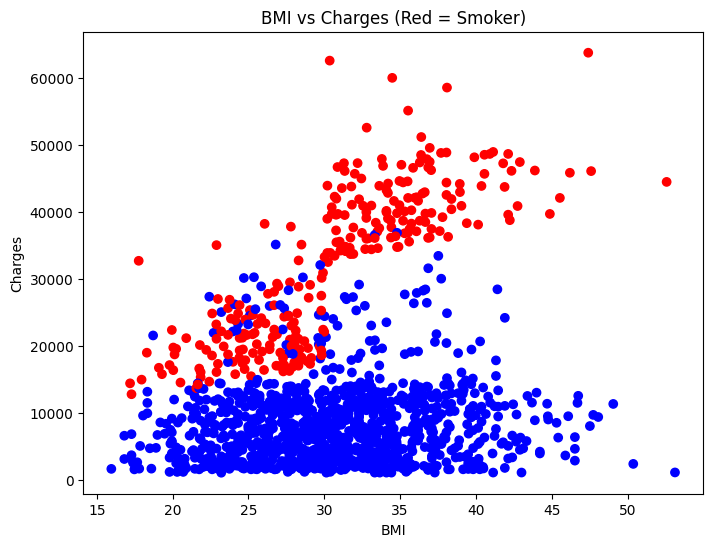

In [9]:
import matplotlib.pyplot as plt

colors = df['smoker'].map({1:'red', 0:'blue'})

plt.figure(figsize=(8,6))
plt.scatter(df['bmi'], df['charges'], c=colors)

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges (Red = Smoker)")

plt.show()

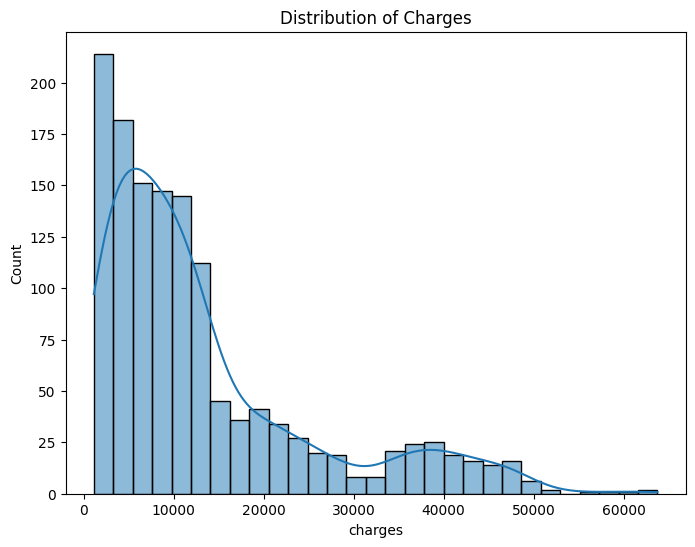

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df['charges'], kde=True)

plt.title("Distribution of Charges")

plt.show()

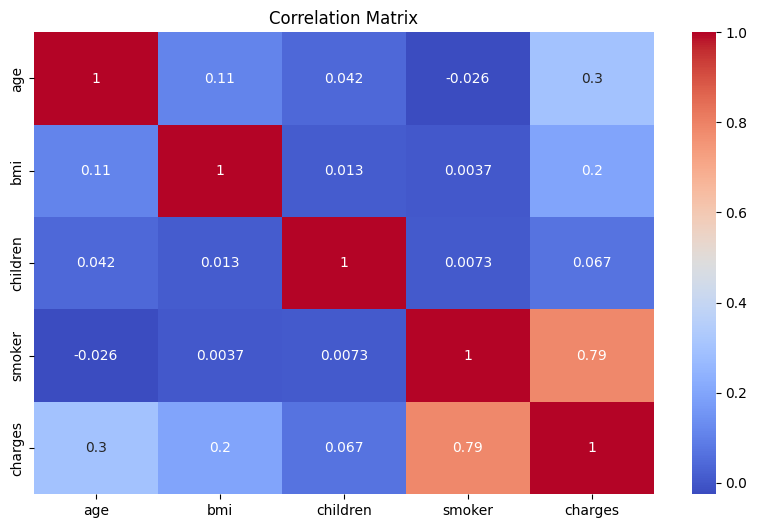

In [11]:
plt.figure(figsize=(10,6))

# Only numeric columns
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [12]:
print("---- DATA MATRIX (First 10 rows) ----")
df[['age','bmi','children','charges']].head(10)

---- DATA MATRIX (First 10 rows) ----


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
5,31,25.740,0,3756.62160
6,46,33.440,1,8240.58960
7,37,27.740,3,7281.50560
8,37,29.830,2,6406.41070
9,60,25.840,0,28923.13692
